# Class Exercise 
- Web Scaping
- Descriptive Statistics 
- Exploratory Data Analysis (EDA)

## Web Scraping

### CSV Files

In [3]:
import pandas as pd
URL = 'https://data.cityofnewyork.us/api/views/e5c5-ieuv/rows.csv'
df_csv = pd.read_csv(URL)
df_csv.head()

,Report Category,Geographic Subdivision,Grade,Year,Student Category,Number Tested,Mean Scale Score,Num Level 1,Pct Level 1,Num Level 2,Pct Level 2,Num Level 3,Pct Level 3,Num Level 4,Pct Level 4,Num Level 3 and 4,Pct Level 3 and 4
0,Citywide,Citywide,3,2006,All Students,73413,674,6714,9.1,11431,15.6,37330,50.8,17938,24.4,55268,75.3
1,Citywide,Citywide,3,2007,All Students,72196,683,3907,5.4,8918,12.4,38117,52.8,21254,29.4,59371,82.2
2,Citywide,Citywide,3,2008,All Students,70062,685,2143,3.1,6854,9.8,44370,63.3,16695,23.8,61065,87.2
3,Citywide,Citywide,3,2009,All Students,71376,689,922,1.3,5196,7.3,47401,66.4,17857,25,65258,91.4
4,Citywide,Citywide,3,2010,All Students,71351,690,8555,12,24086,33.8,22957,32.2,15753,22.1,38710,54.3


In [4]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369542 entries, 0 to 369541
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Report Category         369542 non-null  object
 1   Geographic Subdivision  369542 non-null  object
 2   Grade                   369542 non-null  object
 3   Year                    369542 non-null  int64 
 4   Student Category        369542 non-null  object
 5   Number Tested           369542 non-null  int64 
 6   Mean Scale Score        322592 non-null  object
 7   Num Level 1             369542 non-null  object
 8   Pct Level 1             369542 non-null  object
 9   Num Level 2             369542 non-null  object
 10  Pct Level 2             369542 non-null  object
 11  Num Level 3             369542 non-null  object
 12  Pct Level 3             369542 non-null  object
 13  Num Level 4             369542 non-null  object
 14  Pct Level 4             369542 non-n

### JSON Data

In [5]:
# import urllib library 
from urllib.request import urlopen 
# import json 
import json 

# store the URL in url as parameter for urlopen 
# url = "https://data.cityofnewyork.us/api/views/7yig-nj52/rows.json"
url = 'https://data.cityofnewyork.us/api/views/e5c5-ieuv/rows.json' 
# store the response of URL 
response = urlopen(url) 
  
# storing the JSON response from url in data 
data_json = json.loads(response.read()) 
  
# print the json response 
print(type(data_json)) 

<class 'dict'>


In [6]:
data = data_json.get('data')
data = [x[8:] for x in data]
# data

In [7]:
data_json = pd.DataFrame(data, columns=['Report Category', 'Geographic Subdivision', 'Grade', 'Year', 'Student Category', 'Number Tested',
                                        'Mean Scale Score', 'Num Level 1', 'Pct Level 1', 'Num Level 2',
                                        'Pct Level 2', 'Num Level 3', 'Pct Level 3', 'Num Level 4',
                                        'Pct Level 4', 'Num Level 3 and 4', 'Pct Level 3 and 4'])
data_json.head()

,Report Category,Geographic Subdivision,Grade,Year,Student Category,Number Tested,Mean Scale Score,Num Level 1,Pct Level 1,Num Level 2,Pct Level 2,Num Level 3,Pct Level 3,Num Level 4,Pct Level 4,Num Level 3 and 4,Pct Level 3 and 4
0,Citywide,Citywide,3,2006,All Students,73413,674,6714,9.1,11431,15.6,37330,50.8,17938,24.4,55268,75.3
1,Citywide,Citywide,3,2007,All Students,72196,683,3907,5.4,8918,12.4,38117,52.8,21254,29.4,59371,82.2
2,Citywide,Citywide,3,2008,All Students,70062,685,2143,3.1,6854,9.8,44370,63.3,16695,23.8,61065,87.2
3,Citywide,Citywide,3,2009,All Students,71376,689,922,1.3,5196,7.3,47401,66.4,17857,25,65258,91.4
4,Citywide,Citywide,3,2010,All Students,71351,690,8555,12,24086,33.8,22957,32.2,15753,22.1,38710,54.3


In [8]:
data_json.shape

(369542, 17)

In [9]:
data_json['Geographic Subdivision'].sort_values(ascending=True).value_counts()

Geographic Subdivision
20K104    546
10X095    543
11X089    543
11X083    543
10X020    542
         ... 
84K737      2
84K734      2
84K712      2
84K386      2
84K379      2
Name: count, Length: 1297, dtype: int64

### XML Data

In [10]:
# install bs4
# !pip install bs4

from bs4 import BeautifulSoup
with open("path/to/local/file.xml", "r") as f:
    soup = BeautifulSoup(f, "lxml")
    
print(soup.prettify())

print(f"Root element: {soup.find().name}")

for row in soup.find_all('district')[:5]:  
    print(row.prettify())

In [14]:
# reading xml file from a remote url 
from bs4 import BeautifulSoup
import requests
url = 'https://data.cityofnewyork.us/api/views/e5c5-ieuv/rows.xml'
response = requests.get(url)
soup = BeautifulSoup(response.content, 'lxml')

In [15]:
# Print the root element
print(f"Root element: {soup.find().name}")

Root element: html


In [16]:
# Print the first 500 characters to inspect the structure
print("Response content:")
print(response.text[:500])  

Response content:
<response><row><row _id="row-m2vs_9tv8_zv9p" _uuid="00000000-0000-0000-F63D-B096C0DFDA72" _position="0" _address="https://data.cityofnewyork.us/resource/e5c5-ieuv/row-m2vs_9tv8_zv9p"><report_type>Citywide</report_type><geography>Citywide</geography><grade>3</grade><year>2006</year><demographic>All Students</demographic><number_tested>73413</number_tested><mean_scale_score>674</mean_scale_score><num_level_1>6714</num_level_1><pct_level_1>9.1</pct_level_1><num_level_2>11431</num_level_2><pct_level


In [17]:
# Example: Iterate through specific tags
for row in soup.find_all("geography")[:5]:  # Limit to the first 5 rows
    print(row.prettify())  # Pretty-print the XML structure for the tag


<geography>
 Citywide
</geography>

<geography>
 Citywide
</geography>

<geography>
 Citywide
</geography>

<geography>
 Citywide
</geography>

<geography>
 Citywide
</geography>



In [18]:
# Find all 'row' elements
rows = soup.find_all('row')
print(f"Number of 'row' tags found: {len(rows)}")
    
# Limit processing to the first 10 rows for demonstration
print("Processing first 10 rows...")
for i, row in enumerate(rows[:10], 1):  # Adjust the number to process more rows
    print(f"Row {i}:")
    print(f"Report Type: {row.report_type.text}")
    print(f"Geography: {row.geography.text}")
    print(f"Grade: {row.grade.text}")
    print(f"Year: {row.year.text}")
    print("-" * 50)

Number of 'row' tags found: 369543
Processing first 10 rows...
Row 1:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2006
--------------------------------------------------
Row 2:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2006
--------------------------------------------------
Row 3:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2007
--------------------------------------------------
Row 4:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2008
--------------------------------------------------
Row 5:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2009
--------------------------------------------------
Row 6:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2010
--------------------------------------------------
Row 7:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2011
--------------------------------------------------
Row 8:
Report Type: Citywide
Geography: Citywide
Grade: 3
Year: 2012
----------------------------

In [19]:
# let's grab some data
data = []

for _, row in enumerate(rows[:20000]):
    record = [
        row.geography.text,
        row.year.text,
        row.grade.text,
        row.number_tested.text,
        row.mean_scale_score.text,
        row.num_level_1.text,
        row.num_level_2.text
    ]
    data.append(record)

In [21]:
import pandas as pd
df_xml = pd.DataFrame(data, columns=['geography', 'year', 'grade','number_tested', 'mean_scale_score', 'num_level_1', 'num_level_2'])
df_xml.head()

,geography,year,grade,number_tested,mean_scale_score,num_level_1,num_level_2
0,Citywide,2006,3,73413,674,6714,11431
1,Citywide,2006,3,73413,674,6714,11431
2,Citywide,2007,3,72196,683,3907,8918
3,Citywide,2008,3,70062,685,2143,6854
4,Citywide,2009,3,71376,689,922,5196


In [22]:
df_xml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   geography         20000 non-null  object
 1   year              20000 non-null  object
 2   grade             20000 non-null  object
 3   number_tested     20000 non-null  object
 4   mean_scale_score  20000 non-null  object
 5   num_level_1       20000 non-null  object
 6   num_level_2       20000 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB


In [23]:
# convert date type
df_xml['year'] = pd.to_numeric(df_xml['year'], errors='coerce')
df_xml['number_tested'] = pd.to_numeric(df_xml['number_tested'], errors='coerce')
df_xml['mean_scale_score'] = pd.to_numeric(df_xml['mean_scale_score'], errors='coerce')
df_xml['num_level_1'] = pd.to_numeric(df_xml['num_level_1'], errors='coerce')
df_xml['num_level_2'] = pd.to_numeric(df_xml['num_level_2'], errors='coerce')

In [24]:
df_xml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   geography         20000 non-null  object 
 1   year              20000 non-null  int64  
 2   grade             20000 non-null  object 
 3   number_tested     20000 non-null  int64  
 4   mean_scale_score  19926 non-null  float64
 5   num_level_1       19926 non-null  float64
 6   num_level_2       19926 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


## Descriptive Statistics

In [25]:
average_score = df_xml['mean_scale_score'].mean()
print(f'Average score:{average_score:.2f}')
med_score = df_xml['mean_scale_score'].median()
print(f'Median score:{med_score:.2f}')
standard_deviation = df_xml['mean_scale_score'].std()
print(f'Standard-deviation:{standard_deviation:.2f}')

Average score:670.71
Median score:672.00
Standard-deviation:21.19


In [26]:
# numeric data description
df_xml.describe().T

,count,mean,std,min,25%,50%,75%,max
year,20000.0,2008.999250,2.000112,2006.0,2007.0,2009.0,2011.00,2012.0
number_tested,20000.0,4429.739100,17206.601867,1.0,410.0,1115.5,2597.25,446197.0
mean_scale_score,19926.0,670.705510,21.190389,580.0,658.0,672.0,685.00,733.0
num_level_1,19926.0,414.025243,1699.361007,0.0,28.0,89.0,241.00,70090.0
num_level_2,19926.0,1175.627070,4702.510629,0.0,92.0,272.5,699.00,150751.0


In [27]:
# categorical data description
df_xml.describe(include=[object]).T

,count,unique,top,freq
geography,20000,38,Citywide,540
grade,20000,7,3,2864


In [28]:
df_xml.describe(include='all').T

# this does not look pretty

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geography,20000,38,Citywide,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,20000.0,NaN,NaN,NaN,2008.99925,2.000112,2006.0,2007.0,2009.0,2011.0,2012.0
grade,20000,7,3,2864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_tested,20000.0,NaN,NaN,NaN,4429.7391,17206.601867,1.0,410.0,1115.5,2597.25,446197.0
mean_scale_score,19926.0,NaN,NaN,NaN,670.70551,21.190389,580.0,658.0,672.0,685.0,733.0
num_level_1,19926.0,NaN,NaN,NaN,414.025243,1699.361007,0.0,28.0,89.0,241.0,70090.0
num_level_2,19926.0,NaN,NaN,NaN,1175.62707,4702.510629,0.0,92.0,272.5,699.0,150751.0


## Data Visualization

### Box Plots

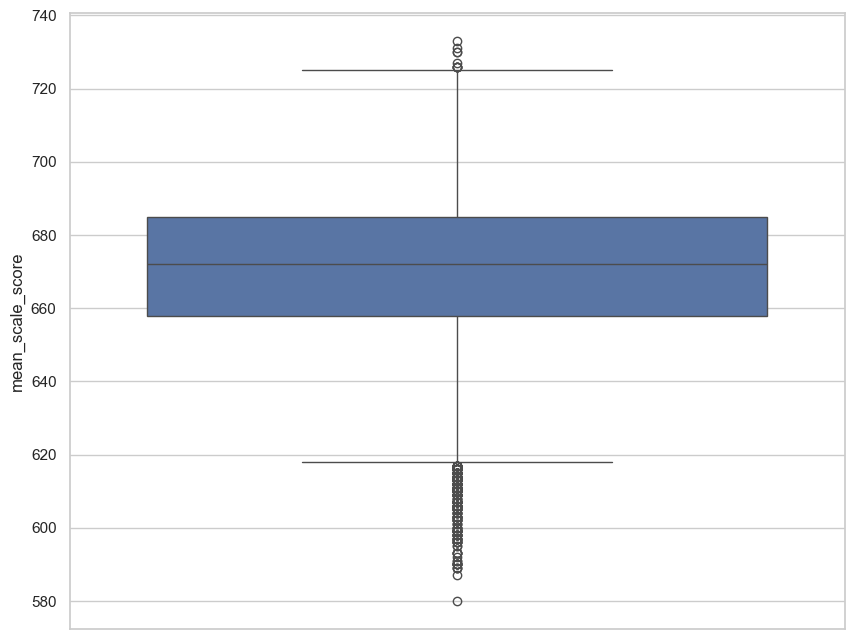

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")
plt.figure(figsize=(10,8))
ax = sns.boxplot(y='mean_scale_score', data=df_xml, orient="v")

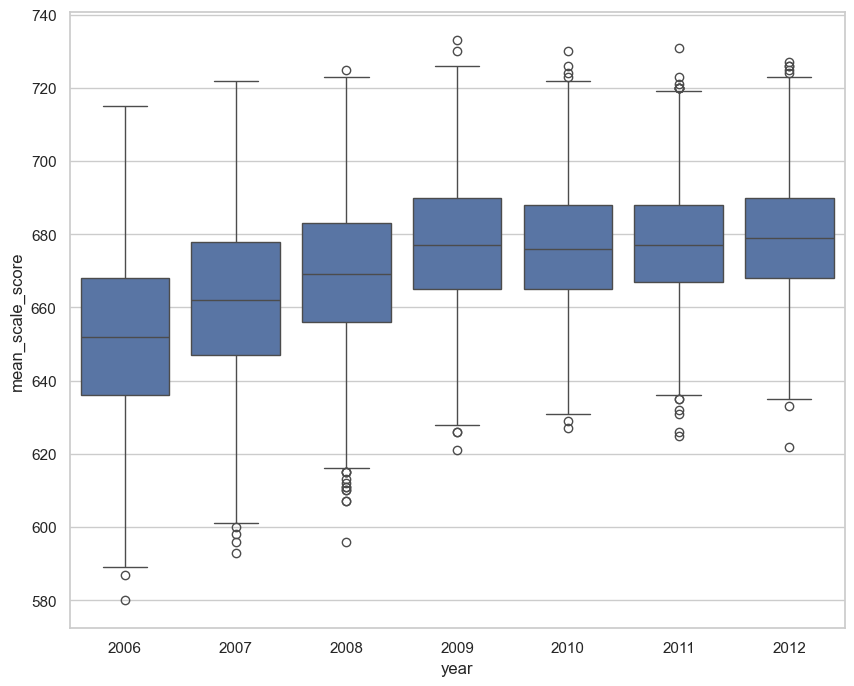

In [30]:
plt.figure(figsize=(10,8))
ax = sns.boxplot(x='year', y='mean_scale_score', data=df_xml, orient="v")

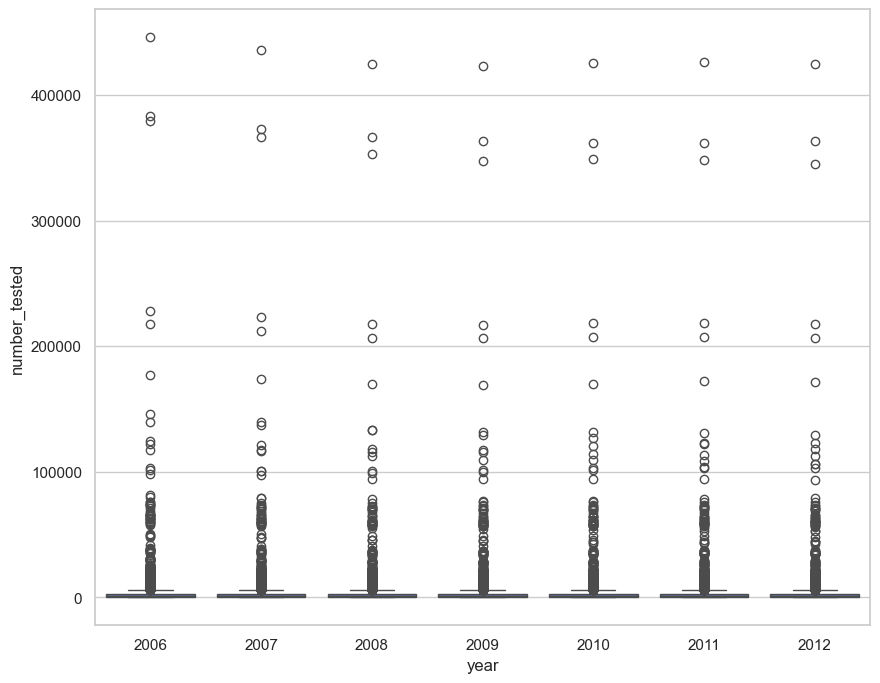

In [31]:
plt.figure(figsize=(10,8))
ax = sns.boxplot(x='year', y='number_tested', data=df_xml, orient="v")

### Distribution plots

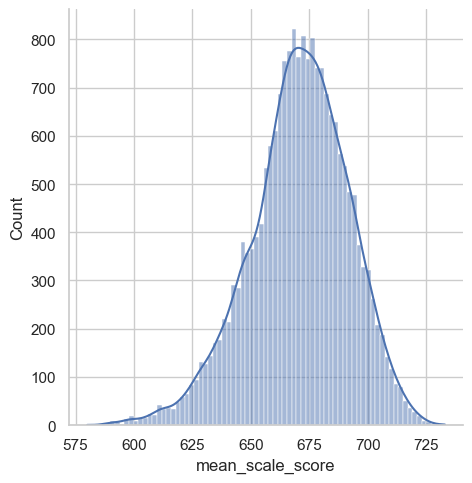

In [32]:
sns.displot(df_xml, x='mean_scale_score', kde=True)

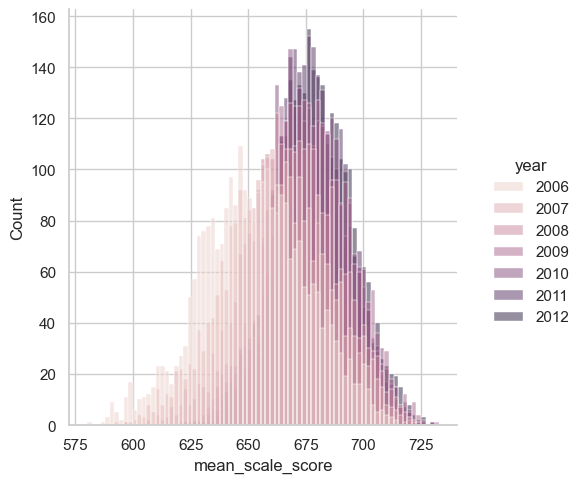

In [33]:
sns.displot(df_xml, x='mean_scale_score', hue="year")

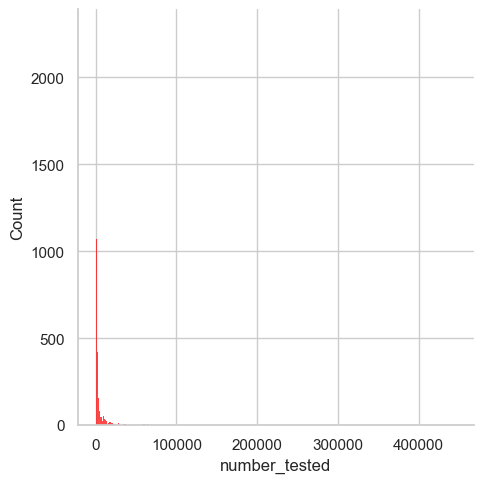

In [34]:
sns.displot(df_xml, x='number_tested', color='red')

Text(0.5, 1.0, 'On Log_Scale')

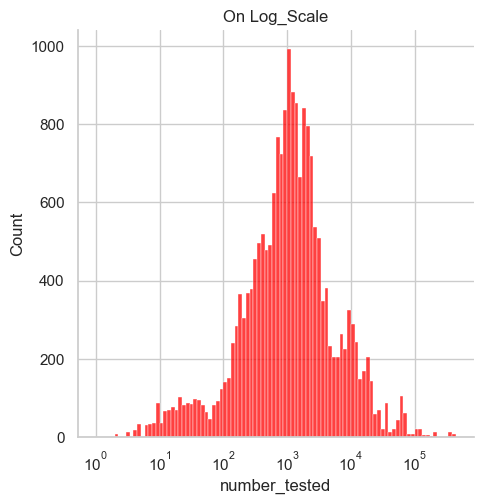

In [35]:
# Let's have closer look
sns.displot(df_xml, x='number_tested', color='red', log_scale=True)
plt.title('On Log_Scale')

### Correlation

<Axes: >

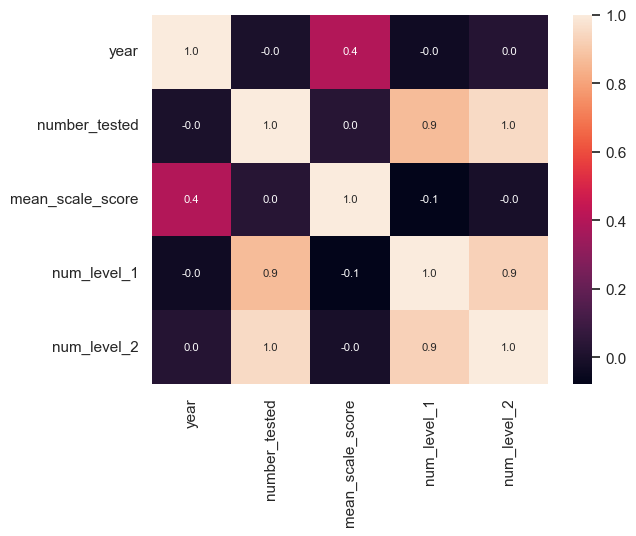

In [50]:
df_numeric = df_xml.select_dtypes(include=["float64", "int64"])

corr = df_numeric.corr()
sns.heatmap(corr, annot=True, fmt=".1f", annot_kws={"fontsize":8})



### ScatterPLOt Matrix (SPLOM)

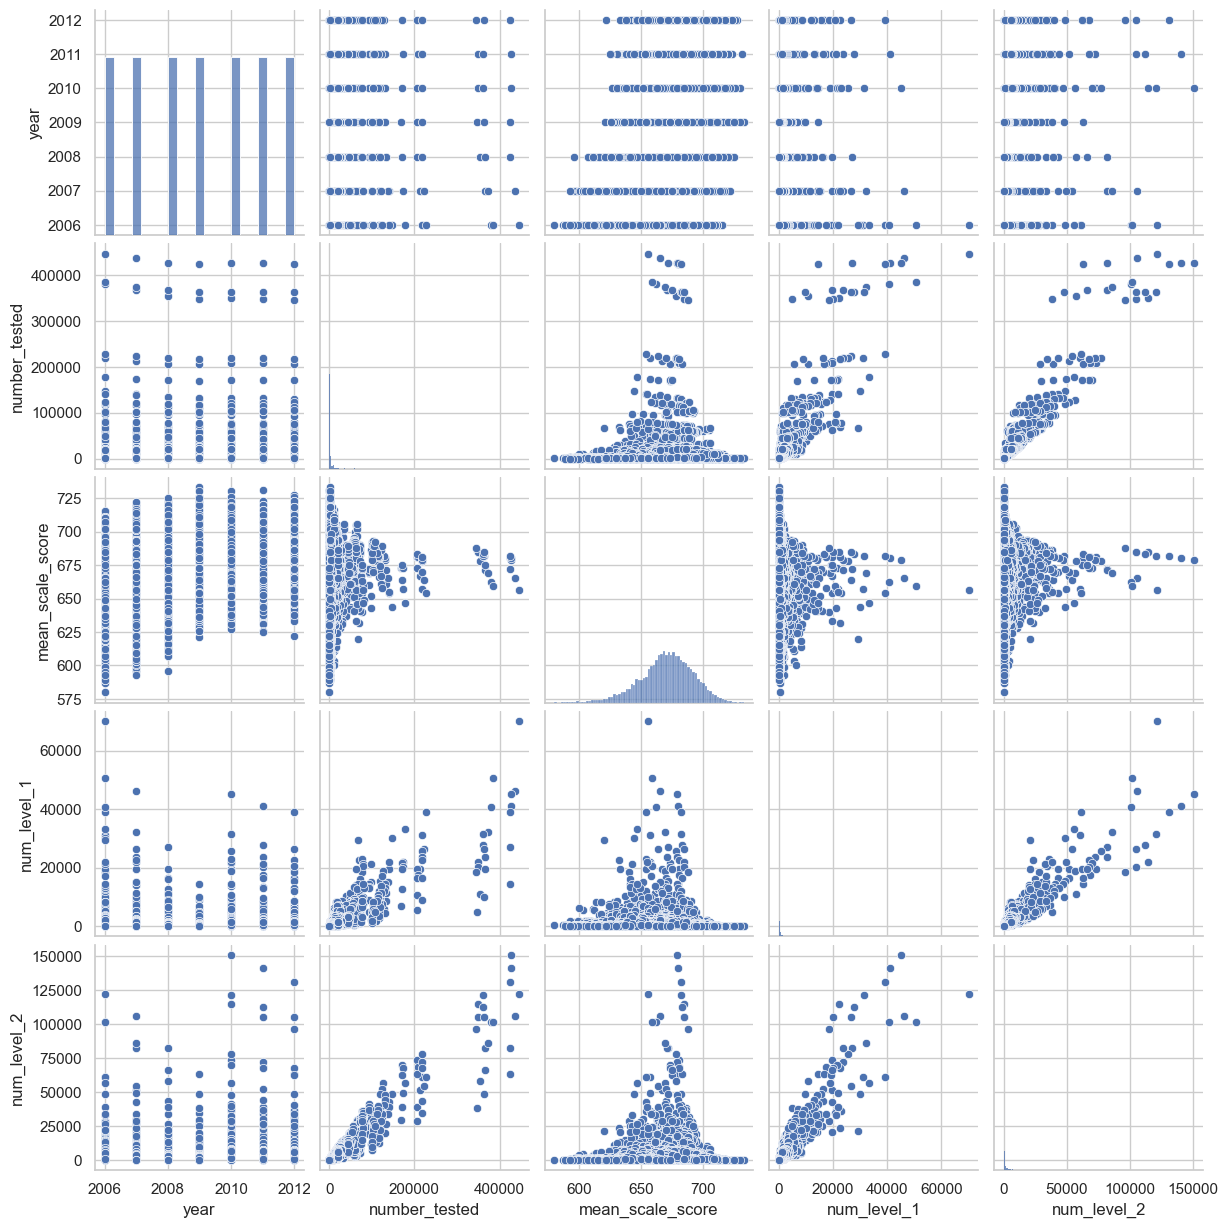

In [37]:
sns.pairplot(df_xml)

### More plot options

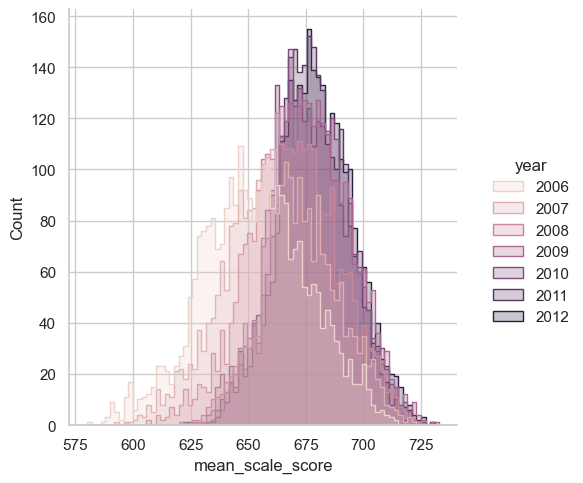

In [38]:
sns.displot(df_xml, x='mean_scale_score', hue="year", element="step")

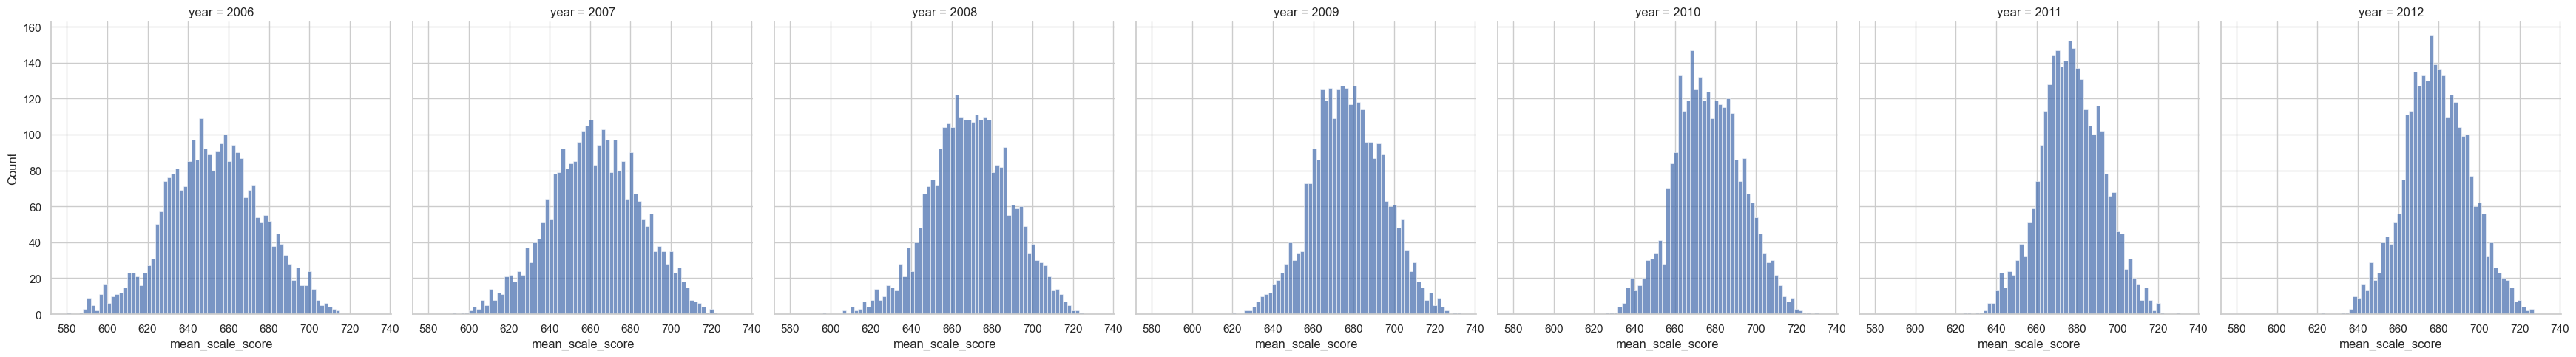

In [39]:
sns.displot(df_xml, x='mean_scale_score', col="year")

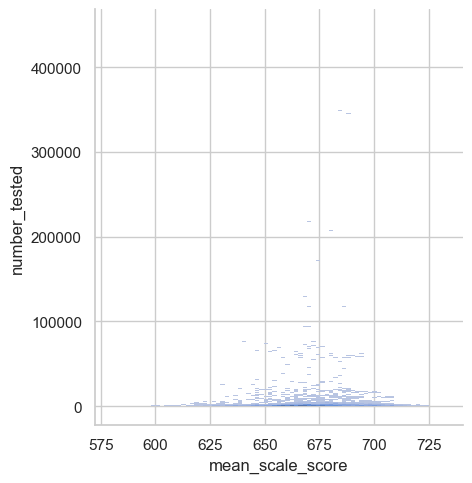

In [40]:
sns.displot(df_xml, x='mean_scale_score', y="number_tested")

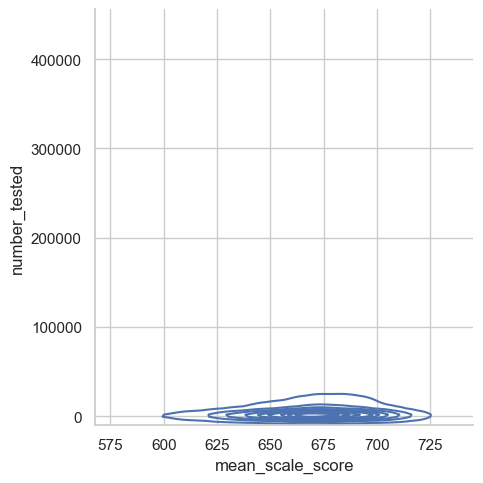

In [41]:
sns.displot(df_xml, x='mean_scale_score', y="number_tested", kind="kde")

# plt.ylim(-10000, 30000) # zoom in

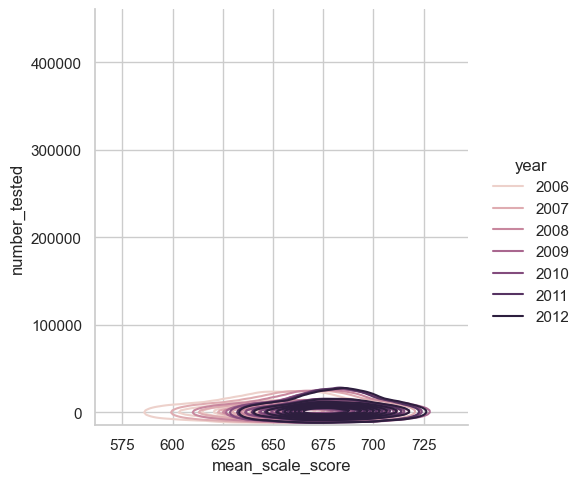

In [43]:
sns.displot(df_xml, x='mean_scale_score', y="number_tested", hue="year", kind="kde")

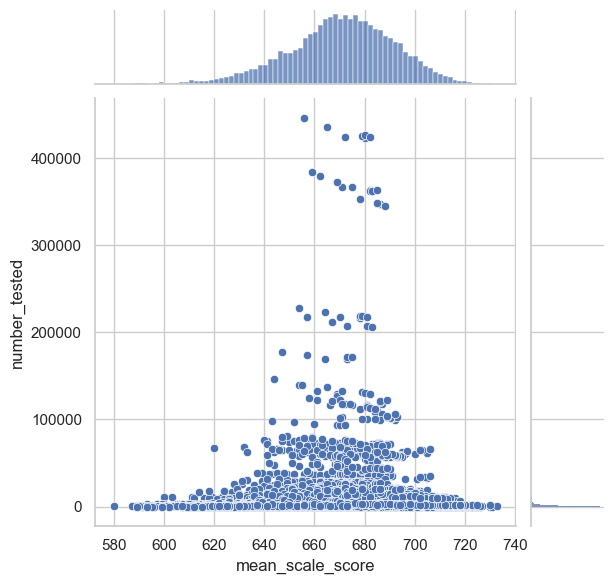

In [44]:
sns.jointplot(data=df_xml, x='mean_scale_score', y="number_tested")

In [ ]:
sns.jointplot(
data=df_xml,
x='mean_scale_score', y="number_tested", hue="year",
kind="kde"
)

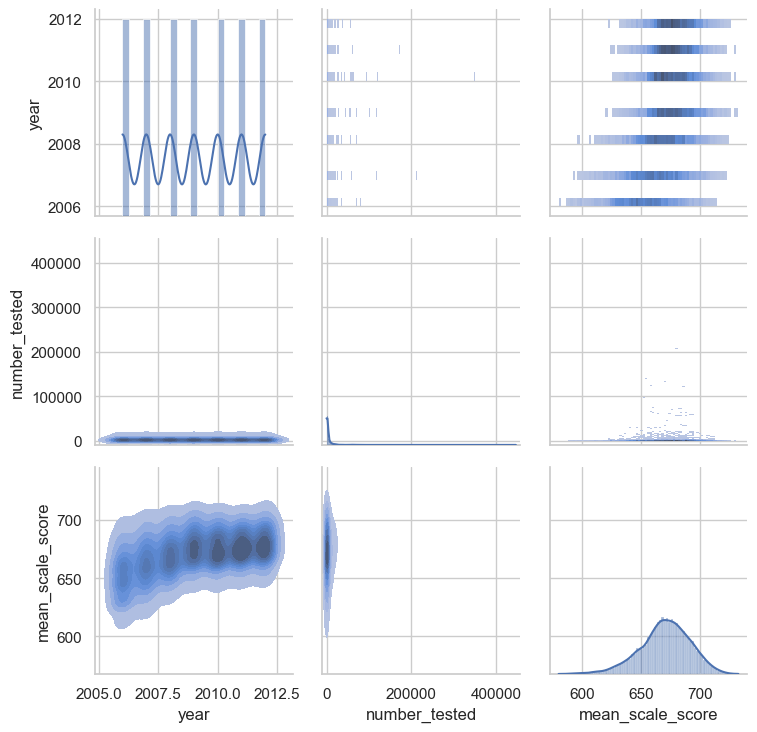

In [35]:
g = sns.PairGrid(df_xml[['year', 'number_tested', 'mean_scale_score']])
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)